In [1]:
import pandas as pd
import seaborn as sns

In [2]:
omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,flagged,flag_reason
0,EP300--HAT_KAT11,P19_0052_BTR_01,missense,24,7.687498,0.000000,4.960262,11.323363,False,NaN
1,EP300--HAT_KAT11,P19_0052_BTR_01,nonsense,1,3.850000,0.271178,0.219063,17.162378,False,NaN
2,EP300--HAT_KAT11,P19_0052_BTR_01,essential_splice,1,7.443651,0.131117,0.423787,33.104662,False,NaN
3,EP300--HAT_KAT11,P19_0052_BTR_01,truncating,2,5.063281,0.070808,0.838437,15.782886,False,NaN
4,EP300--HAT_KAT11,P19_0052_BTR_01,nonsynonymous_splice,26,7.400049,0.000000,4.860622,10.754541,False,NaN


In [5]:
reduced_omegas = omegas[(omegas["gene"].isin(["TP53", "RBM10"]))
                            & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                            & (omegas["impact"].isin(['missense', 'truncating']))
                            ]
reduced_omegas

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,flagged,flag_reason
421,RBM10,CallerDeepumicaller,missense,140,4.689063,0.000000,3.871712,5.639380,False,NaN
424,RBM10,CallerDeepumicaller,truncating,339,65.275391,0.000000,55.645320,76.460083,False,NaN
597,TP53,CallerDeepumicaller,missense,48,4.795313,0.000000,3.514283,6.379785,False,NaN
600,TP53,CallerDeepumicaller,truncating,5,3.264063,0.027920,1.161156,7.119653,False,NaN
1243,RBM10,CallerDupcaller,missense,280,2.572656,0.000000,2.222919,2.969385,False,NaN
1246,RBM10,CallerDupcaller,truncating,504,27.848438,0.000000,24.196172,32.053149,False,NaN
1536,TP53,CallerDupcaller,missense,84,3.674976,0.000000,2.895631,4.605151,False,NaN
1539,TP53,CallerDupcaller,truncating,8,2.520313,0.024903,1.140131,4.766406,False,NaN


In [4]:
# horizontal barplot
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


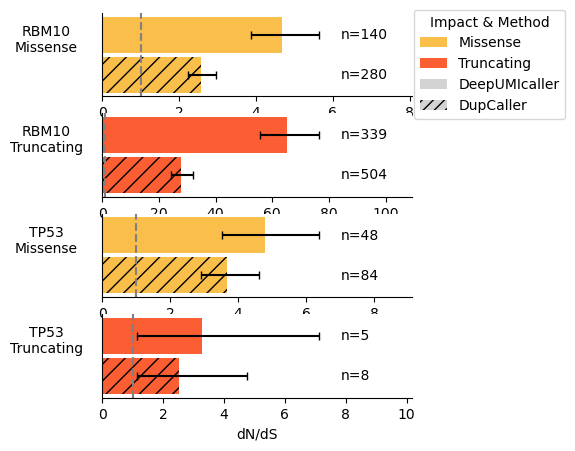

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Create figure with 4 subplots: 2 for RBM10 and 2 for TP53 (missense and truncating separately for both)
fig, (ax_rbm_mis, ax_rbm_tru, ax_tp53_mis, ax_tp53_tru) = plt.subplots(4, 1, figsize=(4, 5), height_ratios=[1, 1, 1, 1])

# Define common parameters
palette = {"truncating": "#FA5E32", "missense": "#FABE4A"}


# Helper function to style bars
def style_gene_segments(ax, data, label, impact_filter=None):
    # Filter data if impact_filter is provided
    plot_data = data.copy()
    if impact_filter:
        plot_data = plot_data[plot_data['impact'] == impact_filter]
    
    # Standardize data order
    plot_data = plot_data.sort_values(['impact', 'sample'])
    
    if plot_data.empty:
        return

    # Use gap to separate impact groups and width to make bars thinner
    sns.barplot(
        y="impact", x="dnds", data=plot_data,
        hue="sample", palette={"CallerDeepumicaller": "#cccccc", "CallerDupcaller": "#cccccc"},
        ax=ax, gap=0.1, width=0.6
    )
    
    # Determine the maximum x value to align text
    max_x = max(plot_data['upper'].fillna(plot_data['dnds']).max(), plot_data['dnds'].max())
    text_x_pos = max_x * 1.1 # Add padding relative to scale
    
    num_hues = len(plot_data['sample'].unique())
    num_categories = len(plot_data['impact'].unique())
    bars = ax.patches
    
    # We iterate and assign attributes based on data indices
    for hue_idx in range(num_hues):
        sample_names = plot_data['sample'].unique()
        if hue_idx >= len(sample_names): continue
        sample_name = sample_names[hue_idx]
        for cat_idx in range(num_categories):
            impact_names = plot_data['impact'].unique()
            if cat_idx >= len(impact_names): continue
            impact_name = impact_names[cat_idx]
            
            # Find the actual bar patch
            bar_idx = hue_idx * num_categories + cat_idx
            if bar_idx >= len(bars): continue
            bar = bars[bar_idx]
            
            # Apply Style
            bar.set_facecolor(palette[impact_name])
            if "Dupcaller" in sample_name:
                bar.set_hatch('//')
            
            # Mutation Count Text
            row = plot_data[(plot_data['impact'] == impact_name) & (plot_data['sample'] == sample_name)]
            if not row.empty:
                count = row['mutations'].values[0]
                lower = row['lower'].values[0]
                upper = row['upper'].values[0]
                dnds = row['dnds'].values[0]
                
                # Add Error Bars (Confidence Intervals)
                if not (pd.isna(lower) or pd.isna(upper)):
                    # Handle symmetric vs asymmetric error bars correctly
                    xerr = [[max(0, dnds - lower)], [max(0, upper - dnds)]]
                    ax.errorbar(dnds, bar.get_y() + bar.get_height()/2, xerr=xerr, 
                                fmt='none', ecolor='black', capsize=3)

                # Mutation Count Text (aligned to the right)
                ax.text(text_x_pos, bar.get_y() + bar.get_height()/2, f'n={count}', 
                         va='center', ha='left', fontsize=10)

    ax.axvline(x=1, color='grey', linestyle='--')
    ax.set_ylabel(label, rotation = 0, labelpad=40)
    ax.set_xlabel('dN/dS')
    ax.set_yticks([])
    # Adjust x-limits to accommodate the right-aligned text
    ax.set_xlim(right=text_x_pos * 1.3)
    if ax.get_legend(): ax.get_legend().remove()

# Execute for RBM10 separated into two axes
rbm10_data = reduced_omegas[reduced_omegas["gene"] == "RBM10"]
style_gene_segments(ax_rbm_mis, rbm10_data, "RBM10\nMissense", impact_filter="missense")
style_gene_segments(ax_rbm_tru, rbm10_data, "RBM10\nTruncating", impact_filter="truncating")

# Execute for TP53 separated into two axes
tp53_data = reduced_omegas[reduced_omegas["gene"] == "TP53"]
style_gene_segments(ax_tp53_mis, tp53_data, "TP53\nMissense", impact_filter="missense")
style_gene_segments(ax_tp53_tru, tp53_data, "TP53\nTruncating", impact_filter="truncating")

# Common Legend
legend_elements = [
    mpatches.Patch(facecolor=palette["missense"], label='Missense'),
    mpatches.Patch(facecolor=palette["truncating"], label='Truncating'),
    mpatches.Patch(facecolor='lightgray', label='DeepUMIcaller'),
    mpatches.Patch(facecolor='lightgray', hatch='///', label='DupCaller')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 0.9), title="Impact & Method")

sns.despine()

# plt.tight_layout()
plt.savefig("../plots/bladder/dnds/TP53_RBM10_all_separate_axes.pdf", bbox_inches='tight')
plt.show()

In [7]:
print(reduced_omegas.to_csv(sep="\t", index=False))

gene	sample	impact	mutations	dnds	pvalue	lower	upper	flagged	flag_reason
RBM10	CallerDeepumicaller	missense	140	4.689062500000008	0.0	3.87171161651612	5.639379882812508	False	
RBM10	CallerDeepumicaller	truncating	339	65.27539062500011	0.0	55.64531971216211	76.46008300781261	False	
TP53	CallerDeepumicaller	missense	48	4.7953125000000085	0.0	3.5142834091186583	6.3797851562500085	False	
TP53	CallerDeepumicaller	truncating	5	3.2640625000000045	0.027920187	1.161156387329103	7.119653320312505	False	
RBM10	CallerDupcaller	missense	280	2.572656250000003	0.0	2.2229187393188505	2.969384765625003	False	
RBM10	CallerDupcaller	truncating	504	27.848437500000053	0.0	24.196171789169355	32.05314941406255	False	
TP53	CallerDupcaller	missense	84	3.6749755859375055	0.0	2.895631412267689	4.605151367187506	False	
TP53	CallerDupcaller	truncating	8	2.5203125000000037	0.02490294	1.1401309204101575	4.766406250000003	False	

